In [1]:
import os
import numpy as np
import pandas as pd
import librosa
import librosa.display
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import tensorflow as tf
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization

DATA_PATH = r"C:\Users\labha\OneDrive\Desktop\Emotion_Recognition\Raw_Data\Ravdess" 

# Audio Settings (Strictly 3 seconds)
SAMPLE_RATE = 22050
DURATION = 3 
SAMPLES_PER_TRACK = SAMPLE_RATE * DURATION

print("✅ Libraries imported. Configuration set.")

✅ Libraries imported. Configuration set.


In [2]:
emotion_map = {
    '01': 'neutral', '02': 'calm', '03': 'happy', '04': 'sad',
    '05': 'angry', '06': 'fearful', '07': 'disgust', '08': 'surprised'
}

data_list = []

for root, dirs, files in os.walk(DATA_PATH):
    for file in files:
        if file.endswith('.wav'):
            # Parse Filename: 03-01-06-01-02-00-12.wav
            parts = file.split('-')
            
            
            emotion_code = parts[2]
            actor_code = int(parts[6].split('.')[0])
            
            
            emotion = emotion_map.get(emotion_code)
            
            
            gender = 'female' if actor_code % 2 == 0 else 'male'
            
            if emotion:
                data_list.append({
                    'path': os.path.join(root, file),
                    'emotion': emotion,
                    'gender': gender
                })


df = pd.DataFrame(data_list)


if df.empty:
    print("❌ Error: No .wav files found! Check your DATA_PATH again.")
else:
    print(f"✅ Success! Found {len(df)} audio files.")
    print("Here are the first 5 examples:")
    print(df.head())
    
    # Optional: Show count per emotion
    print("\nFile count per emotion:")
    print(df['emotion'].value_counts())

✅ Success! Found 2880 audio files.
Here are the first 5 examples:
                                                path  emotion gender
0  C:\Users\labha\OneDrive\Desktop\Emotion_Recogn...  neutral   male
1  C:\Users\labha\OneDrive\Desktop\Emotion_Recogn...  neutral   male
2  C:\Users\labha\OneDrive\Desktop\Emotion_Recogn...  neutral   male
3  C:\Users\labha\OneDrive\Desktop\Emotion_Recogn...  neutral   male
4  C:\Users\labha\OneDrive\Desktop\Emotion_Recogn...     calm   male

File count per emotion:
emotion
calm         384
happy        384
sad          384
angry        384
disgust      384
fearful      384
surprised    384
neutral      192
Name: count, dtype: int64


Comparing:
Angry: C:\Users\labha\OneDrive\Desktop\Emotion_Recognition\Raw_Data\Ravdess\archive\Actor_01\03-01-05-01-01-01-01.wav
Sad: C:\Users\labha\OneDrive\Desktop\Emotion_Recognition\Raw_Data\Ravdess\archive\Actor_01\03-01-04-01-01-01-01.wav


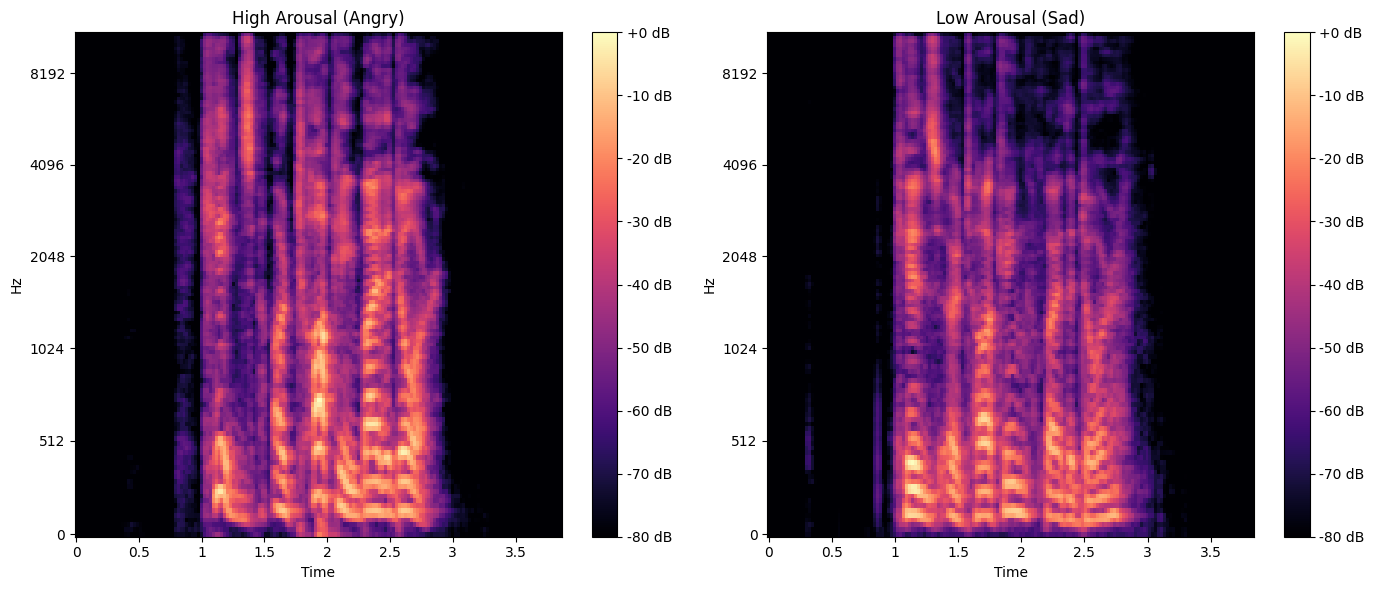

In [3]:
angry_path = df[df['emotion']=='angry']['path'].iloc[0]
sad_path = df[df['emotion']=='sad']['path'].iloc[0]

print(f"Comparing:\nAngry: {angry_path}\nSad: {sad_path}")


def plot_comparison(angry_p, sad_p):
    plt.figure(figsize=(14, 6))

    
    plt.subplot(1, 2, 1)
    
    y_angry, sr = librosa.load(angry_p)
    
    spec_angry = librosa.feature.melspectrogram(y=y_angry, sr=sr)
    spec_angry_db = librosa.power_to_db(spec_angry, ref=np.max)
    
    librosa.display.specshow(spec_angry_db, x_axis='time', y_axis='mel')
    plt.colorbar(format='%+2.0f dB')
    plt.title('High Arousal (Angry)')

    
    plt.subplot(1, 2, 2)
    
    y_sad, sr = librosa.load(sad_p)
    
    spec_sad = librosa.feature.melspectrogram(y=y_sad, sr=sr)
    spec_sad_db = librosa.power_to_db(spec_sad, ref=np.max)
    
    librosa.display.specshow(spec_sad_db, x_axis='time', y_axis='mel')
    plt.colorbar(format='%+2.0f dB')
    plt.title('Low Arousal (Sad)')

    plt.tight_layout()
    plt.show()


plot_comparison(angry_path, sad_path)

In [4]:
def extract_features(file_path):
    try:
        
        y, sr = librosa.load(file_path, sr=SAMPLE_RATE)
        
        
        y_trimmed, _ = librosa.effects.trim(y, top_db=20)
        
        
        if len(y_trimmed) > SAMPLES_PER_TRACK:
            
            y_fixed = y_trimmed[:int(SAMPLES_PER_TRACK)]
        else:
            
            padding = int(SAMPLES_PER_TRACK) - len(y_trimmed)
            y_fixed = np.pad(y_trimmed, (0, padding), 'constant')
            
        
        mel_spec = librosa.feature.melspectrogram(y=y_fixed, sr=sr, n_mels=128, fmax=8000)
        log_mel_spec = librosa.power_to_db(mel_spec, ref=np.max)
        
        return log_mel_spec
        
    except Exception as e:
        print(f"Error processing {file_path}: {e}")
        return None


print("⏳ Processing 2880 files... Please wait.")

X = []  
Y = []  


for index, row in df.iterrows():
    feature = extract_features(row['path'])
    if feature is not None:
        X.append(feature)
        Y.append(row['emotion'])


X = np.array(X)
Y = np.array(Y)


X = X[..., np.newaxis] 

print("✅ Processing Complete!")
print(f"Features Shape: {X.shape}") 
print(f"Labels Shape: {Y.shape}")   

⏳ Processing 2880 files... Please wait.
✅ Processing Complete!
Features Shape: (2880, 128, 130, 1)
Labels Shape: (2880,)


✅ Data Augmentation Engine is Ready!


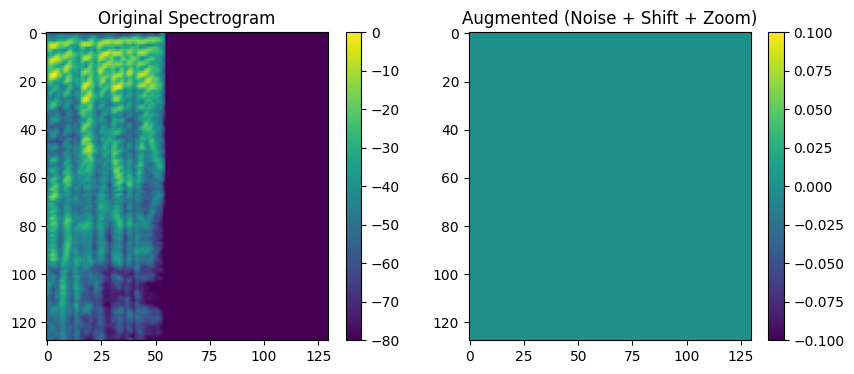

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# --- 1. Define Custom Noise Injection Function ---
def add_noise(img):
    """Adds random grain (Gaussian noise) to the spectrogram image"""
    noise_factor = 0.05 # Adjust this: 0.01 is subtle, 0.1 is heavy
    noise = np.random.normal(loc=0.0, scale=noise_factor, size=img.shape)
    img_noisy = img + noise
    return np.clip(img_noisy, 0.0, 1.0) # Keep pixel values valid

# --- 2. Setup the "Remix Engine" (Data Generator) ---
datagen = ImageDataGenerator(
    width_shift_range=0.1,      # Time Shifting (10%)
    height_shift_range=0.05,    # Pitch Shifting (5%)
    zoom_range=0.1,             # Time Stretching (Zooming in/out)
    fill_mode='nearest',        # Fill empty space with nearest pixels
    preprocessing_function=add_noise # <--- Applies Noise Injection!
)

print("✅ Data Augmentation Engine is Ready!")

# --- 3. VISUAL PROOF ---
# We take the first sample from X array
sample_image = X[0] 
# Reshape for the generator (1, 128, 130, 1)
sample_input = sample_image.reshape((1,) + sample_image.shape) 

# Generate one augmented batch
augmented_images = next(datagen.flow(sample_input, batch_size=1))

# Plot Comparison
plt.figure(figsize=(10, 4))

# Original
plt.subplot(1, 2, 1)
plt.imshow(sample_image.squeeze(), cmap='viridis', aspect='auto')
plt.title("Original Spectrogram")
plt.colorbar()

# Augmented
plt.subplot(1, 2, 2)
plt.imshow(augmented_images[0].squeeze(), cmap='viridis', aspect='auto')
plt.title("Augmented (Noise + Shift + Zoom)")
plt.colorbar()

plt.show()

Old Range: -80.00 to 0.00
✅ New Range: 0.00 to 1.00


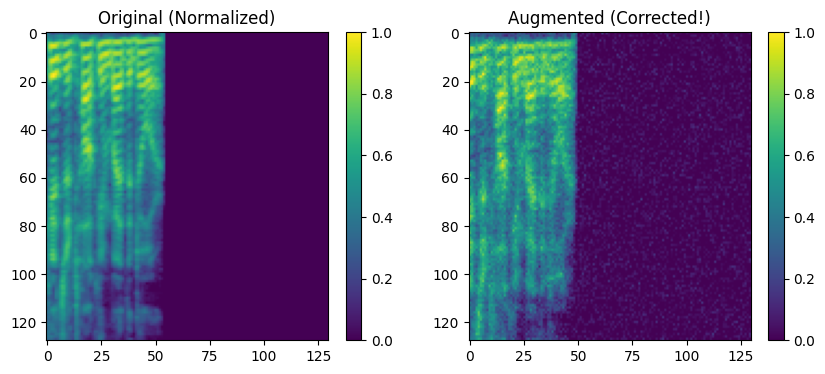

In [6]:
# --- 1. Normalize X to range [0, 1] ---
# This converts -80dB to 0.0 and 0dB to 1.0
print(f"Old Range: {X.min():.2f} to {X.max():.2f}")

X_min = X.min()
X_max = X.max()
X = (X - X_min) / (X_max - X_min)

print(f"✅ New Range: {X.min():.2f} to {X.max():.2f}")

# --- 2. Retry the Augmentation Plot ---
# Now that data is 0-to-1, the previous code will work perfectly!

# Re-define the generator just to be safe
datagen = ImageDataGenerator(
    width_shift_range=0.1,  
    height_shift_range=0.05, 
    zoom_range=0.1,         
    fill_mode='nearest',    
    preprocessing_function=add_noise # Uses your add_noise function
)

# Plot again
sample_image = X[0]
sample_input = sample_image.reshape((1,) + sample_image.shape)
augmented_images = next(datagen.flow(sample_input, batch_size=1))

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.imshow(sample_image.squeeze(), cmap='viridis', aspect='auto')
plt.title("Original (Normalized)")
plt.colorbar()

plt.subplot(1, 2, 2)
plt.imshow(augmented_images[0].squeeze(), cmap='viridis', aspect='auto')
plt.title("Augmented (Corrected!)")
plt.colorbar()
plt.show()

In [7]:
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical
from sklearn.preprocessing import LabelEncoder

# 1. Encode Labels
le = LabelEncoder()
y_encoded = le.fit_transform(Y)
y_categorical = to_categorical(y_encoded)

# 2. Split Data (80% Train, 10% Val, 10% Test)
X_train, X_test, y_train, y_test = train_test_split(X, y_categorical, test_size=0.1, stratify=y_encoded, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.1, stratify=y_train, random_state=42)

print(f"✅ Data Ready for Model: {X_train.shape}")

✅ Data Ready for Model: (2332, 128, 130, 1)


In [8]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization

# Initialize the "Empty" Brain
model = Sequential()

# --- CONVOLUTIONAL BLOCK 1 (The "Ears") ---
# Detects low-level features like edges or simple frequencies
model.add(Conv2D(32, (3, 3), padding='same', activation='relu', input_shape=(128, 130, 1)))
model.add(BatchNormalization()) # Stabilizes the learning
model.add(MaxPooling2D(pool_size=(2, 2))) # Shrinks image by 2x
model.add(Dropout(0.2)) # Prevents overfitting

# --- CONVOLUTIONAL BLOCK 2 (The "Pattern Spotter") ---
# Detects shapes (rising pitch, falling pitch)
model.add(Conv2D(64, (3, 3), padding='same', activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(0.2))

# --- CONVOLUTIONAL BLOCK 3 (The "Complex Analyzer") ---
# Detects complex textures (rough voice, shaky voice)
model.add(Conv2D(128, (3, 3), padding='same', activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(0.2))

# --- CONVOLUTIONAL BLOCK 4 (Deep Features) ---
model.add(Conv2D(256, (3, 3), padding='same', activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(0.2))

# --- CLASSIFICATION HEAD (The Decision Maker) ---
model.add(Flatten()) # Convert 2D maps to 1D list
model.add(Dense(256, activation='relu'))
model.add(BatchNormalization())
model.add(Dropout(0.3)) # Forget 30% to force generalization

# Output Layer (8 Neurons = 8 Emotions)
model.add(Dense(8, activation='softmax'))

# Compile the Model
model.compile(optimizer='adam', 
              loss='categorical_crossentropy', 
              metrics=['accuracy'])

# Print Summary
model.summary()

C:\Users\labha\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 128, 130, 32)        │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 128, 130, 32)        │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 64, 65, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 64, 65, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 64, 65, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 64, 65, 64)          │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 32, 32, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 32, 32, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 32, 32, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_2                │ (None, 32, 32, 128)         │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 16, 16, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 16, 16, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (None, 16, 16, 256)         │         295,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_3                │ (None, 16, 16, 256)         │           1,024 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_3 (MaxPooling2D)       │ (None, 8, 8, 256)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 8, 8, 256)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 16384)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 256)                 │       4,194,560 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_4                │ (None, 256)                 │           1,024 │
│ (BatchNormalization)                 │                             │              

 Total params: 4,587,400 (17.50 MB)

 Trainable params: 4,585,928 (17.49 MB)

 Non-trainable params: 1,472 (5.75 KB)

In [9]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, GlobalAveragePooling2D, Dense, Dropout, BatchNormalization

# Initialize
model = Sequential()

# --- BLOCK 1 ---
model.add(Conv2D(32, (3, 3), padding='same', activation='relu', input_shape=(128, 130, 1)))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(0.2))

# --- BLOCK 2 ---
model.add(Conv2D(64, (3, 3), padding='same', activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(0.2))

# --- BLOCK 3 ---
model.add(Conv2D(128, (3, 3), padding='same', activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(0.2))

# --- BLOCK 4 ---
model.add(Conv2D(256, (3, 3), padding='same', activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(0.2))

# --- THE CHANGE: GAP INSTEAD OF FLATTEN ---
# Instead of Flatten() -> Dense(Huge), we use GAP
model.add(GlobalAveragePooling2D()) 

# We can still add a dense layer for reasoning, but it will be much smaller now
model.add(Dense(128, activation='relu')) 
model.add(BatchNormalization())
model.add(Dropout(0.4)) # Increased Dropout slightly to further fight overfitting

# Output Layer
model.add(Dense(8, activation='softmax'))

# Compile
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Show the difference
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)                    │ (None, 128, 130, 32)        │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_5                │ (None, 128, 130, 32)        │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_4 (MaxPooling2D)       │ (None, 64, 65, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_5 (Dropout)                  │ (None, 64, 65, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_5 (Conv2D)                    │ (None, 64, 65, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_6                │ (None, 64, 65, 64)          │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_5 (MaxPooling2D)       │ (None, 32, 32, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_6 (Dropout)                  │ (None, 32, 32, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_6 (Conv2D)                    │ (None, 32, 32, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_7                │ (None, 32, 32, 128)         │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_6 (MaxPooling2D)       │ (None, 16, 16, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_7 (Dropout)                  │ (None, 16, 16, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_7 (Conv2D)                    │ (None, 16, 16, 256)         │         295,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_8                │ (None, 16, 16, 256)         │           1,024 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_7 (MaxPooling2D)       │ (None, 8, 8, 256)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_8 (Dropout)                  │ (None, 8, 8, 256)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d             │ (None, 256)                 │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 128)                 │          32,896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_9                │ (None, 128)                 │             5

 Total params: 424,200 (1.62 MB)

 Trainable params: 422,984 (1.61 MB)

 Non-trainable params: 1,216 (4.75 KB)

In [10]:
# --- SETTINGS ---
BATCH_SIZE = 32
EPOCHS = 50 

# --- TRAIN THE NEW MODEL ---
print(f"🚀 Starting Training with Global Average Pooling...")

history = model.fit(
    datagen.flow(X_train, y_train, batch_size=BATCH_SIZE), # Feed augmented data
    validation_data=(X_val, y_val), # Check progress on clean data
    epochs=EPOCHS,
    steps_per_epoch=len(X_train) // BATCH_SIZE
)

# --- SAVE THE MODEL ---
model.save('ravdess_emotion_model_GAPfinal.h5')
print("✅ Training Complete & Model Saved!")

🚀 Starting Training with Global Average Pooling...
Epoch 1/50
72/72 ━━━━━━━━━━━━━━━━━━━━ 34s 404ms/step - accuracy: 0.2630 - loss: 2.1220 - val_accuracy: 0.1346 - val_loss: 3.7234
Epoch 2/50
 1/72 ━━━━━━━━━━━━━━━━━━━━ 27s 393ms/step - accuracy: 0.2188 - loss: 2.1001

C:\Users\labha\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\trainers\epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.2188 - loss: 2.1001 - val_accuracy: 0.1346 - val_loss: 3.7047
Epoch 3/50
72/72 ━━━━━━━━━━━━━━━━━━━━ 29s 407ms/step - accuracy: 0.3430 - loss: 1.8491 - val_accuracy: 0.1346 - val_loss: 7.8443
Epoch 4/50
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.3438 - loss: 1.8322 - val_accuracy: 0.1346 - val_loss: 7.8832
Epoch 5/50
72/72 ━━━━━━━━━━━━━━━━━━━━ 29s 398ms/step - accuracy: 0.3622 - loss: 1.7364 - val_accuracy: 0.1346 - val_loss: 11.0576
Epoch 6/50
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.2500 - loss: 1.8738 - val_accuracy: 0.1346 - val_loss: 10.9850
Epoch 7/50
72/72 ━━━━━━━━━━━━━━━━━━━━ 29s 399ms/step - accuracy: 0.3974 - loss: 1.6253 - val_accuracy: 0.1346 - val_loss: 6.7600
Epoch 8/50
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.4688 - loss: 1.3989 - val_accuracy: 0.1346 - val_loss: 6.8285
Epoch 9/50
72/72 ━━━━━━━━━━━━━━━━━━━━ 29s 398ms/step - accuracy: 0.4452 - loss: 1.5081 - val_accuracy: 0.1462 - va

✅ Training Complete & Model Saved!


🔍 Generating predictions on Test Set...
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 82ms/step

📊 --- CLASSIFICATION REPORT ---
              precision    recall  f1-score   support

     Neutral       0.76      0.92      0.83        38
        Calm       0.55      0.61      0.57        38
       Happy       1.00      0.50      0.67        38
         Sad       0.83      0.49      0.61        39
       Angry       0.82      0.23      0.36        39
     Fearful       0.24      0.95      0.38        19
     Disgust       0.48      0.58      0.52        38
   Surprised       0.96      0.64      0.77        39

    accuracy                           0.59       288
   macro avg       0.70      0.61      0.59       288
weighted avg       0.74      0.59      0.60       288



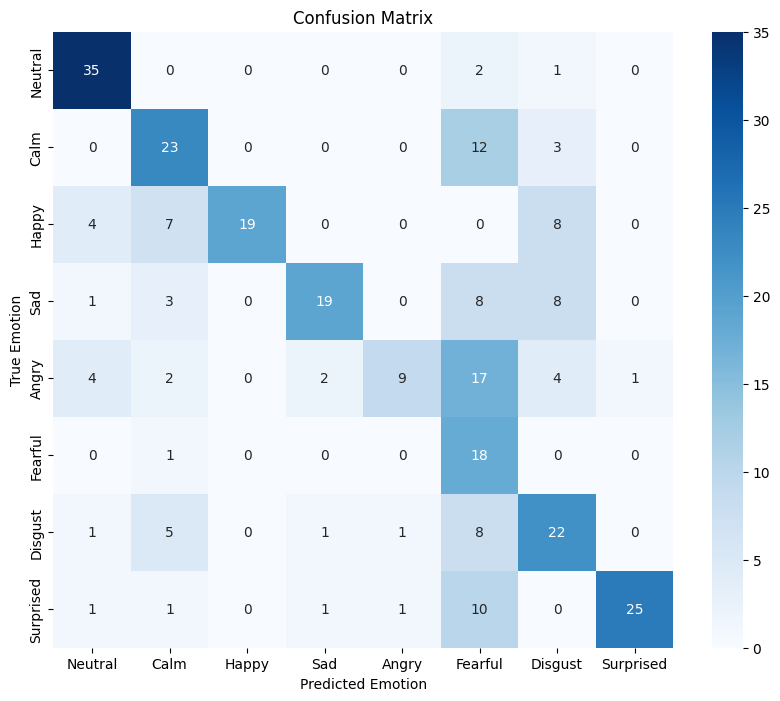

In [11]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

# --- 1. GET PREDICTIONS ---
print("🔍 Generating predictions on Test Set...")
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_test, axis=1)

# --- 2. CLASSIFICATION REPORT (Macro F1-Score) ---
# Map the numbers back to emotion names
emotion_labels = ['Neutral', 'Calm', 'Happy', 'Sad', 'Angry', 'Fearful', 'Disgust', 'Surprised']

print("\n📊 --- CLASSIFICATION REPORT ---")
print(classification_report(y_true, y_pred_classes, target_names=emotion_labels))

# --- 3. CONFUSION MATRIX ---
cm = confusion_matrix(y_true, y_pred_classes)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=emotion_labels, yticklabels=emotion_labels)
plt.xlabel('Predicted Emotion')
plt.ylabel('True Emotion')
plt.title('Confusion Matrix')
plt.show()

In [12]:
from sklearn.model_selection import train_test_split

# Split 1
_, df_test, _, _ = train_test_split(df, y_categorical, test_size=0.1, stratify=y_encoded, random_state=42)

print(f"Test Data Rows: {len(df_test)}")
print(f"X_test Rows:    {len(X_test)}")
assert len(df_test) == len(X_test), "⚠️ Mismatch! Did you reload df? The rows must match."

# --- 2. SEPARATING MALE & FEMALE INDICES --- 
if 'gender' not in df_test.columns:
    df_test['actor_id'] = df_test['path'].apply(lambda x: int(x.split('-')[-1].split('.')[0]))
    df_test['gender'] = df_test['actor_id'].apply(lambda x: 'Male' if x % 2 == 1 else 'Female')

male_indices = df_test[df_test['gender'] == 'Male'].index
female_indices = df_test[df_test['gender'] == 'Female'].index


df_test = df_test.reset_index(drop=True)
male_idx = df_test[df_test['gender'] == 'Male'].index
female_idx = df_test[df_test['gender'] == 'Female'].index


print("\n⚖️ --- PITCH BIAS ANALYSIS ---")

# Evaluate Male
print(f"Testing on {len(male_idx)} Male samples...")
loss_m, acc_m = model.evaluate(X_test[male_idx], y_test[male_idx], verbose=0)

# Evaluate Female
print(f"Testing on {len(female_idx)} Female samples...")
loss_f, acc_f = model.evaluate(X_test[female_idx], y_test[female_idx], verbose=0)

print(f"\n👨 Male Accuracy:   {acc_m*100:.2f}%")
print(f"👩 Female Accuracy: {acc_f*100:.2f}%")

if abs(acc_m - acc_f) > 0.05:
    print("⚠️ BIAS DETECTED: The model significantly favors one gender.")
else:
    print("✅ NO BIAS: The model performs roughly equally for both genders.")

Test Data Rows: 288
X_test Rows:    288

⚖️ --- PITCH BIAS ANALYSIS ---
Testing on 0 Male samples...


C:\Users\labha\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\trainers\epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


ValueError: not enough values to unpack (expected 2, got 0)

In [13]:
import os
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
_, df_test, _, _ = train_test_split(df, y_categorical, test_size=0.1, stratify=y_encoded, random_state=42)

df_test = df_test.reset_index(drop=True)

def get_gender(file_path):
    try:
        
        filename = os.path.basename(file_path) 
        parts = filename.split('-')
        
        actor_id_str = parts[-1].split('.')[0]
        actor_id = int(actor_id_str)
        
        
        if actor_id % 2 == 1:
            return 'Male'
        else:
            return 'Female'
    except:
        return 'Unknown'

df_test['gender'] = df_test['path'].apply(get_gender)


male_idx = df_test[df_test['gender'] == 'Male'].index
female_idx = df_test[df_test['gender'] == 'Female'].index


print(f"Found {len(male_idx)} Male files and {len(female_idx)} Female files.")

print(f"Sample Path: {df_test['path'].iloc[0]}")
print(f"Detected:    {df_test['gender'].iloc[0]}")


print("\n⚖️ --- PITCH BIAS ANALYSIS ---")

if len(male_idx) > 0:
    print(f"Testing on {len(male_idx)} Male samples...")
    loss_m, acc_m = model.evaluate(X_test[male_idx], y_test[male_idx], verbose=0)
    print(f"👨 Male Accuracy:   {acc_m*100:.2f}%")
else:
    print("⚠️ No Male files found! Check your dataframe paths.")
    acc_m = 0

if len(female_idx) > 0:
    print(f"Testing on {len(female_idx)} Female samples...")
    loss_f, acc_f = model.evaluate(X_test[female_idx], y_test[female_idx], verbose=0)
    print(f"👩 Female Accuracy: {acc_f*100:.2f}%")
else:
    print("⚠️ No Female files found!")
    acc_f = 0

# Check for Bias
if len(male_idx) > 0 and len(female_idx) > 0:
    diff = abs(acc_m - acc_f)
    print(f"\nDifference: {diff*100:.2f}%")
    if diff > 0.05:
        print("⚠️ BIAS DETECTED: The model significantly favors one gender.")
    else:
        print("✅ NO BIAS: The model performs roughly equally for both genders.")

Found 147 Male files and 141 Female files.
Sample Path: C:\Users\labha\OneDrive\Desktop\Emotion_Recognition\Raw_Data\Ravdess\archive\audio_speech_actors_01-24\Actor_23\03-01-08-01-02-01-23.wav
Detected:    Male

⚖️ --- PITCH BIAS ANALYSIS ---
Testing on 147 Male samples...
👨 Male Accuracy:   57.14%
Testing on 141 Female samples...
👩 Female Accuracy: 60.99%

Difference: 3.85%
✅ NO BIAS: The model performs roughly equally for both genders.


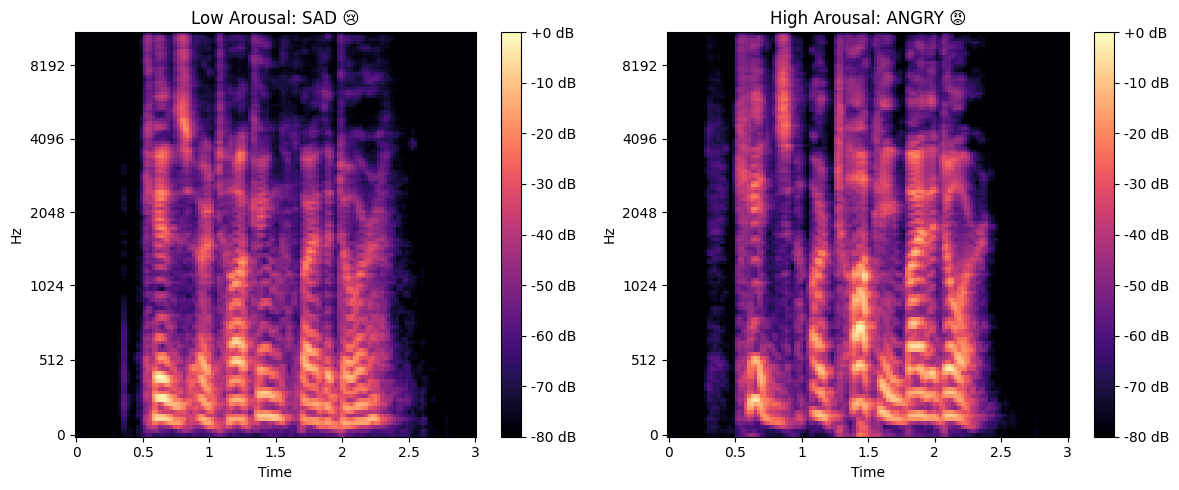

In [14]:
import librosa
import librosa.display
import matplotlib.pyplot as plt
import numpy as np

sad_path = df[df['path'].str.contains('-04-')]['path'].iloc[0]
angry_path = df[df['path'].str.contains('-05-')]['path'].iloc[0]

def get_spectrogram(path):
    y, sr = librosa.load(path, duration=3, offset=0.5)
    S = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128)
    return librosa.power_to_db(S, ref=np.max)

spec_sad = get_spectrogram(sad_path)
spec_angry = get_spectrogram(angry_path)


plt.figure(figsize=(12, 5))

# Sad
plt.subplot(1, 2, 1)
librosa.display.specshow(spec_sad, sr=22050, x_axis='time', y_axis='mel')
plt.title('Low Arousal: SAD 😢')
plt.colorbar(format='%+2.0f dB')

# Angry
plt.subplot(1, 2, 2)
librosa.display.specshow(spec_angry, sr=22050, x_axis='time', y_axis='mel')
plt.title('High Arousal: ANGRY 😡')
plt.colorbar(format='%+2.0f dB')

plt.tight_layout()
plt.show()

In [1]:
import numpy as np
import librosa
import tensorflow as tf
import sys

# --- CONFIGURATION ---
MODEL_PATH = 'ravdess_emotion_model_GAPfinal.h5'
EMOTIONS = {
    0: 'Neutral',
    1: 'Calm',
    2: 'Happy',
    3: 'Sad',
    4: 'Angry',
    5: 'Fearful',
    6: 'Disgust',
    7: 'Surprised'
}

def preprocess_audio(file_path):
    """
    Loads and processes an audio file to match the training data format.
    1. Load 3 seconds of audio.
    2. Convert to Mel Spectrogram.
    3. Resize/Pad to exactly (128, 130).
    4. Normalize.
    """
    try:
        y, sr = librosa.load(file_path, duration=3, offset=0.5)
        
        S = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128)
        log_S = librosa.power_to_db(S, ref=np.max)
        
        
        if log_S.shape[1] < 130:
            pad_width = 130 - log_S.shape[1]
            log_S = np.pad(log_S, ((0, 0), (0, pad_width)), mode='constant')
        
        else:
            log_S = log_S[:, :130]
            
        
        norm_S = (log_S - log_S.min()) / (log_S.max() - log_S.min())
        
        
        return norm_S.reshape(1, 128, 130, 1)
        
    except Exception as e:
        print(f"Error processing file: {e}")
        return None

def predict_emotion(file_path):
    print("Loading model...")
    model = tf.keras.models.load_model(MODEL_PATH)
    
    print(f"Processing audio: {file_path}...")
    processed_data = preprocess_audio(file_path)
    
    if processed_data is not None:
        
        predictions = model.predict(processed_data)
        
        class_id = np.argmax(predictions)
        confidence = np.max(predictions) * 100
        emotion = EMOTIONS.get(class_id, "Unknown")
        
        print(f"\n🎧 Prediction Result:")
        print(f"--------------------------")
        print(f"🗣️  Emotion:    {emotion.upper()}")
        print(f"📊 Confidence: {confidence:.2f}%")
        print(f"--------------------------")
        return emotion
    else:
        print("Failed to process audio.")


In [2]:
import random


random_file = df.sample(1)['path'].iloc[0]


predict_emotion(random_file)

NameError: name 'df' is not defined

In [3]:
import os
import pandas as pd

DATA_PATH = r"C:\Users\labha\OneDrive\Desktop\Emotion_Recognition\Raw_Data\Ravdess\archive"


file_paths = []
print("Scanning folders...")

for root, dirs, files in os.walk(DATA_PATH):
    for file in files:
        if file.endswith(".wav"):
            file_paths.append(os.path.join(root, file))


df = pd.DataFrame(file_paths, columns=['path'])

print(f"✅ Success! 'df' is restored.")
print(f"Found {len(df)} files.")

Scanning folders...
✅ Success! 'df' is restored.
Found 2880 files.


In [5]:
%%writefile predict.py
import numpy as np
import librosa
import tensorflow as tf
import sys
import os

# --- CONFIGURATION ---
MODEL_PATH = 'ravdess_emotion_model_GAPfinal.h5'

EMOTIONS = {
    0: 'Neutral',
    1: 'Calm',
    2: 'Happy',
    3: 'Sad',
    4: 'Angry',
    5: 'Fearful',
    6: 'Disgust',
    7: 'Surprised'
}

def preprocess_audio(file_path):
    """
    Loads and processes an audio file to match the training data format.
    """
    try:
        y, sr = librosa.load(file_path, duration=3, offset=0.5)
        
        S = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128)
        log_S = librosa.power_to_db(S, ref=np.max)
        
        if log_S.shape[1] < 130:
            pad_width = 130 - log_S.shape[1]
            log_S = np.pad(log_S, ((0, 0), (0, pad_width)), mode='constant')
        else:
            log_S = log_S[:, :130]
            
        norm_S = (log_S - log_S.min()) / (log_S.max() - log_S.min())
        
        return norm_S.reshape(1, 128, 130, 1)
        
    except Exception as e:
        print(f"Error processing file: {e}")
        return None

def predict_emotion(file_path):
    if not os.path.exists(MODEL_PATH):
        print(f"❌ Error: Model file '{MODEL_PATH}' not found.")
        print("Make sure the .h5 file is in the same folder as this script!")
        return

    try:
        model = tf.keras.models.load_model(MODEL_PATH)
    except Exception as e:
        print(f"❌ Error loading model: {e}")
        return

    print(f"Processing audio: {file_path}...")
    processed_data = preprocess_audio(file_path)
    
    if processed_data is not None:
        predictions = model.predict(processed_data)
        class_id = np.argmax(predictions)
        confidence = np.max(predictions) * 100
        emotion = EMOTIONS.get(class_id, "Unknown")
        
        print(f"\n🎧 Prediction Result:")
        print(f"--------------------------")
        print(f"🗣️  Emotion:    {emotion.upper()}")
        print(f"📊 Confidence: {confidence:.2f}%")
        print(f"--------------------------")
        return emotion
    else:
        print("Failed to process audio.")

if __name__ == "__main__":
    if len(sys.argv) > 1:
        audio_path = sys.argv[1]
        predict_emotion(audio_path)
    else:
        print("Usage: python predict.py <path_to_wav_file>")

Writing predict.py
